# Medical Cost Prediction — Data Wrangling

**Problem Statement:**  
Insurance companies face challenges in estimating medical costs accurately, which impacts pricing, policy design and risk management. By applying the Data Science Method to historical medical cost data, we aim to build an accurate cost prediction model.

---

## Table of Contents
1. Data Collection
2. Data Organization
3. Data Definition
4. Data Cleaning

---
## 1. Data Collection
**Goal:** Load the dataset and organize it so it is ready for the next steps.

In [1]:
# Import the libraries we need
import pandas as pd
import numpy as np

In [2]:
# Load the dataset using read_csv()
df = pd.read_csv('/Users/Deepthi/Downloads/medical_cost_prediction_dataset.csv')

# Quick check — show the first 5 rows
df.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,0,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77,Urban,15110,3202.52


In [3]:
# Check how many rows and columns we have
print('Shape of dataset:', df.shape)

Shape of dataset: (5000, 20)


**Note:** This project uses a single CSV file, so no joining or merging is needed at this stage. If additional data sources were available (e.g., a separate demographics table), we could use `pd.merge()` or `pd.concat()` to combine them.

---
## 2. Data Organization
**Goal:** Set up a clear file structure and keep track of our work using GitHub.


In [4]:
# We can use the glob library to list all CSV files in a folder
# This is useful if we have multiple data files
import glob

# List all CSV files in the current directory
csv_files = glob.glob('*.csv')
print('CSV files found:', csv_files)

CSV files found: ['london_weather.csv', 'Seattle_weather.csv', 'medical_cost_cleaned.csv', 'medical_cost_prediction_dataset.csv']


---
## 3. Data Definition
**Goal:** Understand what each column means, its data type, and the range/distribution of values.

In [5]:
# Check column names
print('Column names:')
print(df.columns.tolist())

Column names:
['age', 'gender', 'bmi', 'smoker', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'physical_activity_level', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_type', 'insurance_coverage_pct', 'city_type', 'previous_year_cost', 'annual_medical_cost']


In [6]:
# Check the data types of each column
print('Data types:')
print(df.dtypes)

Data types:
age                          int64
gender                      object
bmi                        float64
smoker                      object
diabetes                     int64
hypertension                 int64
heart_disease                int64
asthma                       int64
physical_activity_level     object
daily_steps                  int64
sleep_hours                float64
stress_level                 int64
doctor_visits_per_year       int64
hospital_admissions          int64
medication_count             int64
insurance_type              object
insurance_coverage_pct       int64
city_type                   object
previous_year_cost           int64
annual_medical_cost        float64
dtype: object


### Column Descriptions

| Column | Description |
|---|---|
| age | Age of the individual |
| gender | Gender (Male / Female) |
| bmi | Body Mass Index |
| smoker | Whether the person smokes (Yes / No) |
| diabetes | Whether the person has diabetes (1 = Yes, 0 = No) |
| hypertension | Whether the person has hypertension (1 = Yes, 0 = No) |
| heart_disease | Whether the person has heart disease (1 = Yes, 0 = No) |
| asthma | Whether the person has asthma (1 = Yes, 0 = No) |
| physical_activity_level | Activity level (Low / Medium / High) |
| daily_steps | Average number of steps per day |
| sleep_hours | Average sleep hours per night |
| stress_level | Stress level score |
| doctor_visits_per_year | Number of doctor visits per year |
| hospital_admissions | Number of hospital admissions |
| medication_count | Number of medications taken |
| insurance_type | Type of insurance (Private / Government / None) |
| insurance_coverage_pct | Percentage of costs covered by insurance |
| city_type | Area type (Urban / Semi-Urban / Rural) |
| previous_year_cost | Medical cost from the previous year |
| annual_medical_cost | **Target variable** — medical cost for the current year |

In [7]:
# Summary statistics for numeric columns
df.describe()

,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,annual_medical_cost
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,53.299000,25.970820,0.207600,0.288000,0.14220,0.096400,7993.216800,6.488140,5.475400,4.030600,1.001000,3.509000,57.953000,10248.515400,8048.886894
std,20.646851,5.046651,0.405629,0.452876,0.34929,0.295169,4052.127069,1.443361,2.892312,2.010689,0.978566,2.292721,31.627742,5626.095015,7071.020228
min,18.000000,6.400000,0.000000,0.000000,0.00000,0.000000,1004.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,500.000000,404.950000
25%,36.000000,22.600000,0.000000,0.000000,0.00000,0.000000,4545.000000,5.200000,3.000000,3.000000,0.000000,1.000000,53.000000,5342.750000,3241.977500
50%,53.000000,25.900000,0.000000,0.000000,0.00000,0.000000,7989.000000,6.500000,5.000000,4.000000,1.000000,3.000000,71.000000,10281.000000,5539.780000
75%,71.000000,29.400000,0.000000,1.000000,0.00000,0.000000,11532.250000,7.700000,8.000000,5.000000,2.000000,6.000000,79.000000,15034.500000,10094.097500
max,89.000000,43.600000,1.000000,1.000000,1.00000,1.000000,14999.000000,9.000000,10.000000,14.000000,6.000000,7.000000,94.000000,19996.000000,44792.100000


In [8]:
# Count unique values for each column
print('Unique value counts per column:')
print(df.nunique())

Unique value counts per column:
age                          72
gender                        2
bmi                         294
smoker                        2
diabetes                      2
hypertension                  2
heart_disease                 2
asthma                        2
physical_activity_level       3
daily_steps                4184
sleep_hours                  51
stress_level                 10
doctor_visits_per_year       15
hospital_admissions           7
medication_count              8
insurance_type                2
insurance_coverage_pct       46
city_type                     3
previous_year_cost         4376
annual_medical_cost        4986
dtype: int64


In [9]:
# Look at value counts for categorical columns
categorical_cols = ['gender', 'smoker', 'physical_activity_level', 'insurance_type', 'city_type']

for col in categorical_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- gender ---
gender
Female    2519
Male      2481
Name: count, dtype: int64

--- smoker ---
smoker
No     3779
Yes    1221
Name: count, dtype: int64

--- physical_activity_level ---
physical_activity_level
Low       1996
Medium    1986
High      1018
Name: count, dtype: int64

--- insurance_type ---
insurance_type
Private       1979
Government    1973
Name: count, dtype: int64

--- city_type ---
city_type
Urban         2474
Semi-Urban    1503
Rural         1023
Name: count, dtype: int64



In [10]:
# Check the range of key numeric columns
numeric_cols = ['age', 'bmi', 'daily_steps', 'sleep_hours', 'annual_medical_cost']

for col in numeric_cols:
    print(f'{col} — min: {df[col].min()}, max: {df[col].max()}, mean: {round(df[col].mean(), 2)}')

age — min: 18, max: 89, mean: 53.3
bmi — min: 6.4, max: 43.6, mean: 25.97
daily_steps — min: 1004, max: 14999, mean: 7993.22
sleep_hours — min: 4.0, max: 9.0, mean: 6.49
annual_medical_cost — min: 404.95, max: 44792.1, mean: 8048.89


---
## 4. Data Cleaning
**Goal:** Handle missing values, duplicates, and any data quality issues.

In [11]:
# Check for missing (null) values
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Any missing values at all?', df.isnull().values.any())

Missing values per column:
age                           0
gender                        0
bmi                           0
smoker                        0
diabetes                      0
hypertension                  0
heart_disease                 0
asthma                        0
physical_activity_level       0
daily_steps                   0
sleep_hours                   0
stress_level                  0
doctor_visits_per_year        0
hospital_admissions           0
medication_count              0
insurance_type             1048
insurance_coverage_pct        0
city_type                     0
previous_year_cost            0
annual_medical_cost           0
dtype: int64

Any missing values at all? True


In [12]:
# Check for duplicate rows
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
# Drop duplicate rows if any exist
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (5000, 20)


In [14]:
# Check if insurance_coverage_pct is 0 for people with insurance
# This could be a data issue worth flagging
coverage_issue = df[(df['insurance_type'] != 'None') & (df['insurance_coverage_pct'] == 0)]
print('Rows where person has insurance but coverage is 0%:', len(coverage_issue))

Rows where person has insurance but coverage is 0%: 1048


In [15]:
#Mark invalid zeros as NaN (be honest about missingness)
df.loc[(df['insurance_type'] != 'None') & (df['insurance_coverage_pct'] == 0),
       'insurance_coverage_pct'] = np.nan

In [20]:
# Check if binary columns (0/1) only contain expected values
binary_cols = ['diabetes', 'hypertension', 'heart_disease', 'asthma']

for col in binary_cols:
    print(f'{col} unique values: {df[col].unique()}')

diabetes unique values: [1 0]
hypertension unique values: [0 1]
heart_disease unique values: [0 1]
asthma unique values: [0 1]


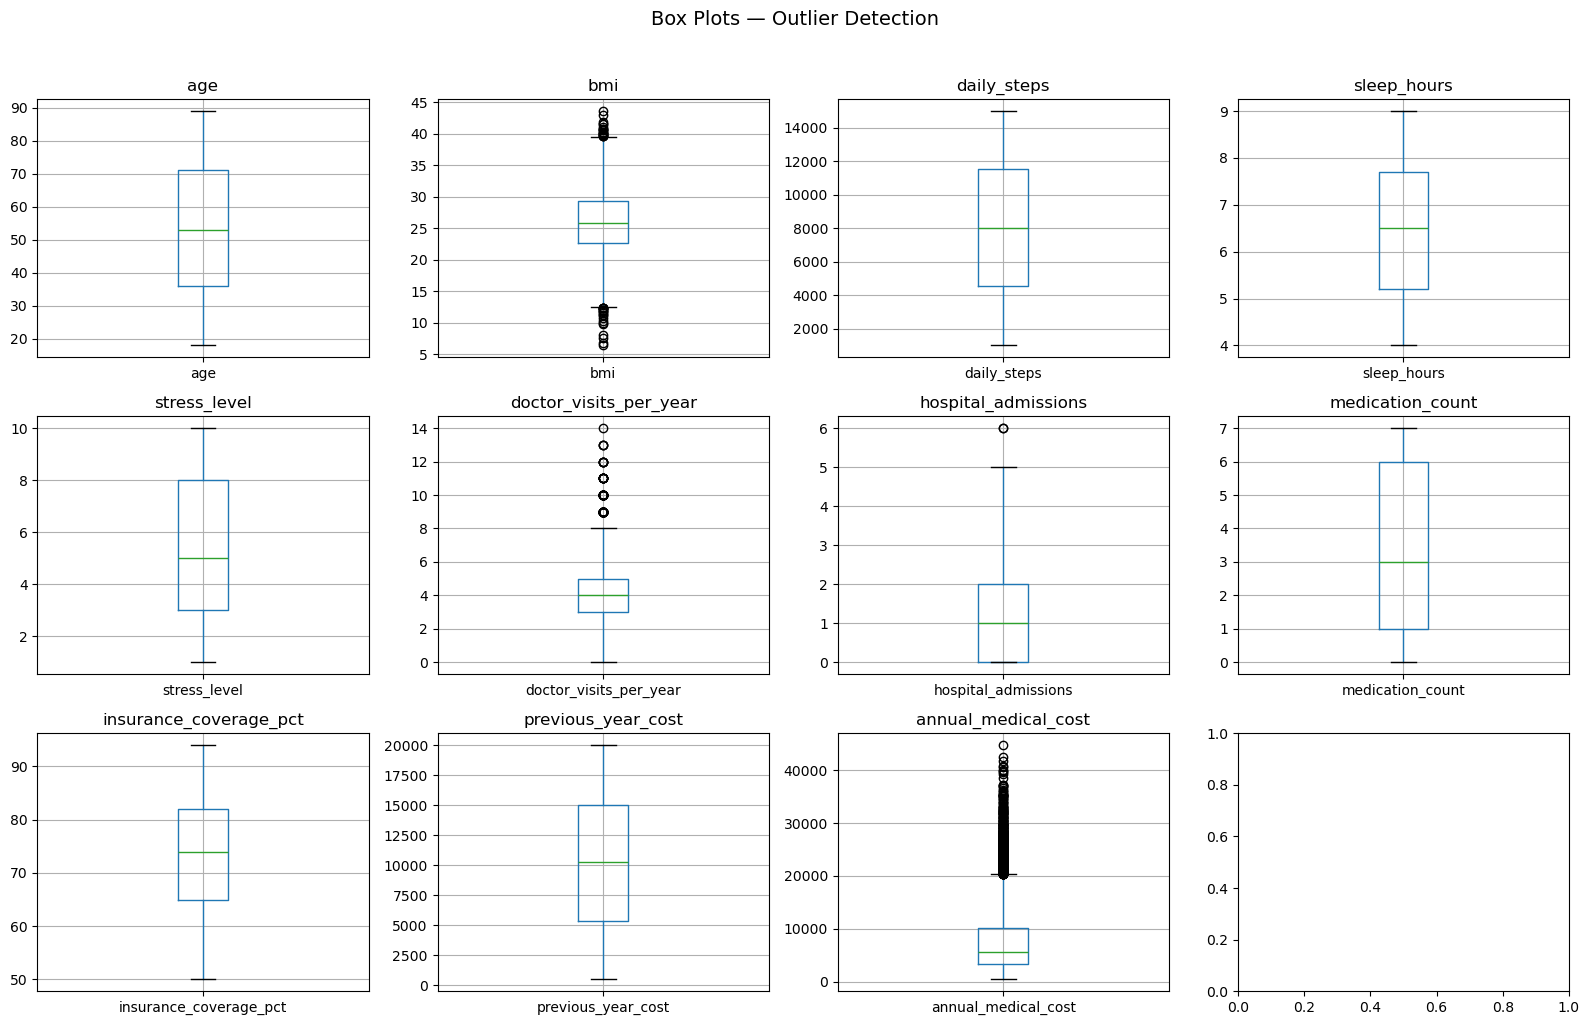

In [23]:
#boxplots for outlier detewction
import matplotlib.pyplot as plt

numeric_cols = ['age', 'bmi', 'daily_steps', 'sleep_hours', 'stress_level',
                'doctor_visits_per_year', 'hospital_admissions',
                'medication_count', 'insurance_coverage_pct',
                'previous_year_cost', 'annual_medical_cost']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Box Plots — Outlier Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#outliers were not removed as it might be genuine,eg: high medical costs .

In [24]:
# Check the smoker column — make sure it only has 'Yes' / 'No'
print('Smoker values:', df['smoker'].unique())

Smoker values: ['No' 'Yes']


In [25]:
# Final check — confirm the cleaned dataset looks good
print('Final dataset shape:', df.shape)
print()
df.head()

Final dataset shape: (5000, 20)



,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80.0,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64.0,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,NaN,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70.0,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77.0,Urban,15110,3202.52


In [26]:
# Save the cleaned dataset for the next stage
df.to_csv('medical_cost_cleaned.csv', index=False)
print('Cleaned dataset saved as medical_cost_cleaned.csv')

Cleaned dataset saved as medical_cost_cleaned.csv


---
## Summary

Here is what was done in the previous steps above : 

- **Data Collection:** Loaded the dataset using `pd.read_csv()`. No joining was needed as we have a single source file.
- **Data Organization:** Defined a clear folder structure and noted the importance of GitHub for version control and collaboration.
- **Data Definition:** Explored all 20 columns — checked data types, summary statistics, unique value counts, and value ranges. The target variable is `annual_medical_cost`.
- **Data Cleaning:** Confirmed there are no missing values. Checked for and removed any duplicate rows. Verified that binary and categorical columns contain only expected values. Flagged a potential consistency check between `insurance_type` and `insurance_coverage_pct`.

The dataset is now clean and ready for the **EDA (Exploratory Data Analysis)** phase.